In [2]:
! pip install pandas numpy matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [4]:
df=pd.read_csv('student_scores.csv')
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [5]:
df.info()              #column names, data types and missing values
df.describe()                 #statistical summary of numerical columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [6]:
df.shape       #DISPLAYS SIZE AND TUPLES

(25, 2)

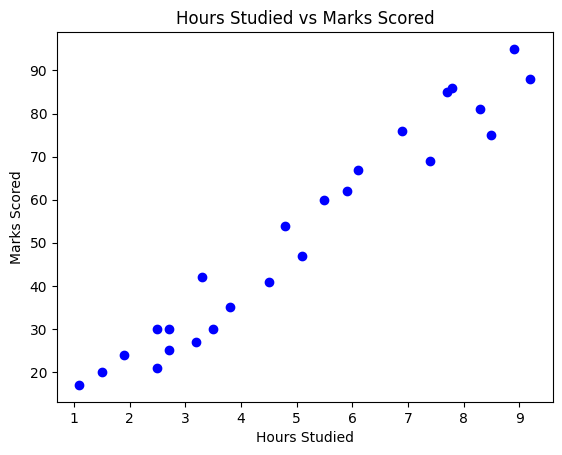

In [7]:
#Relation betn hours and score( hours badhyo vane score ni badhcha) (shows linear regression is suitable as it is not in a straight line)
plt.scatter(df['Hours'], df['Scores'], color='blue')
plt.title('Hours Studied vs Marks Scored')
plt.xlabel('Hours Studied')
plt.ylabel('Marks Scored')
plt.show()

In [8]:
#Split Data into Training and Test Sets (converts pandas to numpy array and reshapes to 2D)
X = df['Hours'].values.reshape(-1, 1)            # Independent variable (Hours)
y = df['Scores'].values.reshape(-1,1)             # Dependent variable (Scores)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)   #trains the model (y=mx+c)

LinearRegression()

In [10]:
y_pred_test= model.predict(X_test)  #predicts le test data ko lagi score nikalcha

In [11]:
mse = mean_squared_error(y_test, y_pred_test)
print(f"Mean Squared Error (MSE) on test set: {mse:.2f}")  #predicts how close prediction are to actual values

Mean Squared Error (MSE) on test set: 18.94


In [12]:
comparison = pd.DataFrame({
    'Actual': np.round(y_test.flatten(), 2),       # flatten le 2d to 1d banaucha, round le 2 decimal samma dekhaucha
    'Predicted': np.round(y_pred_test.flatten(), 2), # Predicted scores
    'Error': np.round(y_test.flatten() - y_pred_test.flatten(), 2)  # Difference (less score vaneko ramro)
})
print("\nActual vs Predicted Scores (Test Set) with Error:\n")
print(comparison)



Actual vs Predicted Scores (Test Set) with Error:

   Actual  Predicted  Error
0      81      83.19  -2.19
1      30      27.03   2.97
2      21      27.03  -6.03
3      76      69.63   6.37
4      62      59.95   2.05


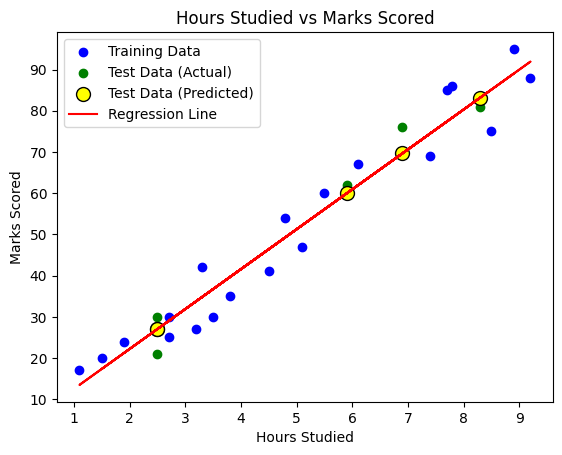

In [13]:
plt.scatter(X_train, y_train, color='blue', label='Training Data')  #model le sikeko pattern
plt.scatter(X_test, y_test, color='green', label='Test Data (Actual)')
plt.scatter(X_test, y_pred_test, color='yellow', edgecolor='black', s=100, label='Test Data (Predicted)')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.xlabel('Hours Studied')              #green ra yellow points najik cha vne ramro predict garyo
plt.ylabel('Marks Scored')                           # yellow points line ko najik bhaye model le data pattern ramrari sikyo
plt.title('Hours Studied vs Marks Scored')
plt.legend()
plt.show()

In [14]:
hours = np.array([[7]])  # 2D input
predicted_score = model.predict(hours)
print(f"Predicted score for a student who studied {hours[0][0]} hours: {predicted_score[0][0]:.2f}")

Predicted score for a student who studied 7 hours: 70.60
